In [1]:
import cv2
import time
import numpy as np
import torch
import random
from torch import Tensor
import json
import os
from os import listdir
from os.path import isfile, join
from torch.nn import BCEWithLogitsLoss
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as xfms
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [3]:
torch.manual_seed(12)
torch.backends.cudnn.deterministic = True

In [4]:
torch.cuda.is_available()

True

In [5]:
#------------------------------------------
# 建立 path_dict，包含 train/val/test 的資料路徑
#------------------------------------------
base_dir = 'size_512'
image_root = os.path.join(base_dir, 'images_crop')
mask_root = os.path.join(base_dir, 'masks_crop')

categories = [d for d in os.listdir(image_root) if os.path.isdir(os.path.join(image_root, d))]

all_data = []
for cat in categories:
    img_dir = os.path.join(image_root, cat)
    mask_dir = os.path.join(mask_root, cat)
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg') or f.endswith('.png')]
    for f in img_files:
        img_path = os.path.join(img_dir, f)
        mask_path = os.path.join(mask_dir, f.replace('.jpg', '.png'))
        if os.path.isfile(mask_path):
            all_data.append((img_path, mask_path))
        else:
            print(f"Mask not found for {img_path}")

random.shuffle(all_data)
n_total = len(all_data)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.1)
n_test = n_total - n_train - n_val

train_data = all_data[:n_train]
val_data = all_data[n_train:n_train+n_val]
test_data = all_data[n_train+n_val:]

path_dict = {"train": train_data, "val": val_data, "test": test_data}


## Create Dataset

In [6]:
#------------------------------------------
# 實作 CCAgT_Dataset (加入 Data Augmentation)
#------------------------------------------
class CCAgT_Dataset(Dataset):
    def __init__(self, img_dict, split='train'):
        self.items = img_dict[split]
        self.split = split

        # 定義基本 transform
        self.img_transform = transforms.ToTensor()

        # 定義訓練集的資料增強
        if self.split == 'train':
            self.aug_transform = transforms.Compose([
                transforms.Resize((512,512)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.3),
                transforms.RandomRotation(degrees=15)
            ])
        else:
            self.aug_transform = transforms.Resize((512,512))
        
        # 定義正規化 (以 ImageNet 統計為例，可依實際資料調整)
        self.normalize_transform = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, mask_path = self.items[idx]
        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        # 先做 size 對齊與資料增強（影像 & mask 一起做，以確保對應關係不變）
        seed = np.random.randint(2147483647)  # 固定 seed 確保 img & mask 增強一致
        random.seed(seed)
        torch.manual_seed(seed)
        img = self.aug_transform(img)
        random.seed(seed)
        torch.manual_seed(seed)
        mask = self.aug_transform(mask)

        # 轉為 Tensor
        img = self.img_transform(img)
        
        # 限制 mask 的類別範圍到 0~7
        mask_np = np.array(mask)
        mask_np[mask_np > 7] = 0  
        mask = torch.from_numpy(mask_np).long()

        # 正規化影像
        img = self.normalize_transform(img)

        return img, mask

In [7]:
#------------------------------------------
# 定義一個簡單的 U-Net 模型
#------------------------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2 , in_channels // 2 , kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, (diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2))
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=8, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [8]:
#------------------------------------------
# DataLoader 設定
#------------------------------------------
img_size = [512, 512]
LR = 1e-4
BATCH = 32
EPOCHS = 100

trainset = CCAgT_Dataset(path_dict, 'train')
trainloader = DataLoader(trainset, batch_size=BATCH, shuffle=True, num_workers=4)
valset = CCAgT_Dataset(path_dict, 'val')
valloader = DataLoader(valset, batch_size=BATCH, shuffle=False, num_workers=4)
testset = CCAgT_Dataset(path_dict, 'test')
testloader = DataLoader(testset, batch_size=BATCH, shuffle=False, num_workers=4)

In [9]:
a = next(iter(trainloader))
print(len(a[0]))

print(f"Train data: {len(train_data)}")
print(f"Validation data: {len(val_data)}")
print(f"Test data: {len(test_data)}")


32
Train data: 14685
Validation data: 2098
Test data: 4197


In [10]:
def contours_generate(input_img,fusion_img):
    input_img = np.float32(input_img)
    img_gray = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
    img_gray *= 255
    colors = [(255,50,0),(131,60,11),(0,255,0),(0,0,255),(255,0,255),(255,0,0),(0,0,128)]
    for threshhold in range(1,8):
        ret, thresh = cv2.threshold(np.uint8(img_gray),(threshhold*36-1), 255, cv2.THRESH_BINARY)
        contours, hierarchy = cv2.findContours(thresh, 3, 2)
        if contours:
            if threshhold == 1:
                hull = cv2.drawContours(fusion_img, contours, -1, colors[threshhold-2], 6)
            else:
                hull = cv2.drawContours(hull, contours, -1, colors[threshhold-2], 6)
        else :
            hull = fusion_img
    return hull

def vs_generate(input_mask, gen_mask, fusion):
    err_space = np.float64(np.logical_xor(input_mask, gen_mask))
    corr_space = np.logical_and(input_mask, gen_mask)
    R,G,B = cv2.split(err_space)
    R[R==0] = 0.18
    G[G==0] = 0.46
    G[G>0.47] = 0
    B[B==0] = 0.71
    B[B>0.72] = 0
    err_space =cv2.merge([R,G,B])
    
    err_space *= np.float64(np.logical_not(corr_space))
    corr_space = np.float64(corr_space)
    corr_space *= fusion
    err_space += corr_space
    return err_space

def compress_channel(input_batch_img, threshold):
    single_img = torch.zeros(1, input_batch_img.size(2), input_batch_img.size(3))
    output_batch_img = torch.zeros(input_batch_img.size(0), 1,
                                   input_batch_img.size(2), input_batch_img.size(3))
    for idx,n in enumerate(input_batch_img):
        for ch,img in enumerate(n):
            single_img[0][ img > threshold ] = ch
        output_batch_img[idx] = single_img
    return output_batch_img

def show_images(input_imgs, input_masks: None, gen_masks= None,
                nrow=5, ncol=1, show: bool = True, save: bool = True, path ="", mode: bool =False):
    if input_imgs.shape[0] < nrow:
        nrow = input_imgs.shape[0]
    figsize = (nrow*3+2,9)
    count = 311
    img_label = ["input\nimages", "input\nmask"]
    inputs = [input_imgs, input_masks]
    offset = -0.1

    if mode == True and gen_masks == None:
        print("Input ERROR! Expected [gen_mask] but got [None].")
        return None
        
    elif mode == True and gen_masks != None:
        figsize = (nrow*3+2,18)
        count = 611
        img_label.append("generated\nmask")
        inputs.append(gen_masks)

    plt.figure(figsize=figsize)
    for imgs, label in zip(inputs, img_label):
        imgs = imgs[:nrow * ncol]

        if len(imgs.shape) == 3:
            imgs = imgs.unsqueeze(1)

        imgs = F.interpolate(imgs, size=(256, 256), mode='bilinear', align_corners=False)

        ax = plt.subplot(count)
        ax.set_title(label, x=offset, y=0.35)
        img_grid = np.transpose(make_grid(imgs, nrow=nrow, padding=2, normalize=True).cpu(), (1, 2, 0))
        img = np.float32(np.array(img_grid))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img.shape[1] * 2, int(img.shape[0] * 1.5)), interpolation=cv2.INTER_AREA)
        plt.axis("off")
        plt.imshow(img)

        if label == "input\nmask":
            input_mask = img
        if label == "generated\nmask":
            gen_mask = img

        if label == "input\nimages":
            origin_img = img/3+0.6
        else :
            count+=1
            ax = plt.subplot(count)
            name = label.split("\n")[0] + "\nfusion"
            ax.set_title(name,x=offset, y=0.35)
            fusion = origin_img.copy()
            contours_generate(img,fusion)
            plt.axis("off")
            plt.imshow(fusion)
        
        if label == "generated\nmask":
            count+=1
            ax = plt.subplot(count)
            name = "ground truth\nvs\ngenerated"
            ax.set_title(name,x=offset, y=0.35)
            fusion = origin_img.copy()
            vs = vs_generate(input_mask, gen_mask, fusion)
            plt.axis("off")
            plt.imshow(vs)
        count+=1
    if save:
        import datetime
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f'./version1_show_{timestamp}.png'
        plt.savefig(save_path)
        print(f"Image saved to {save_path}")
    if show:
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Image saved to ./version1_show_20241220_181513.png


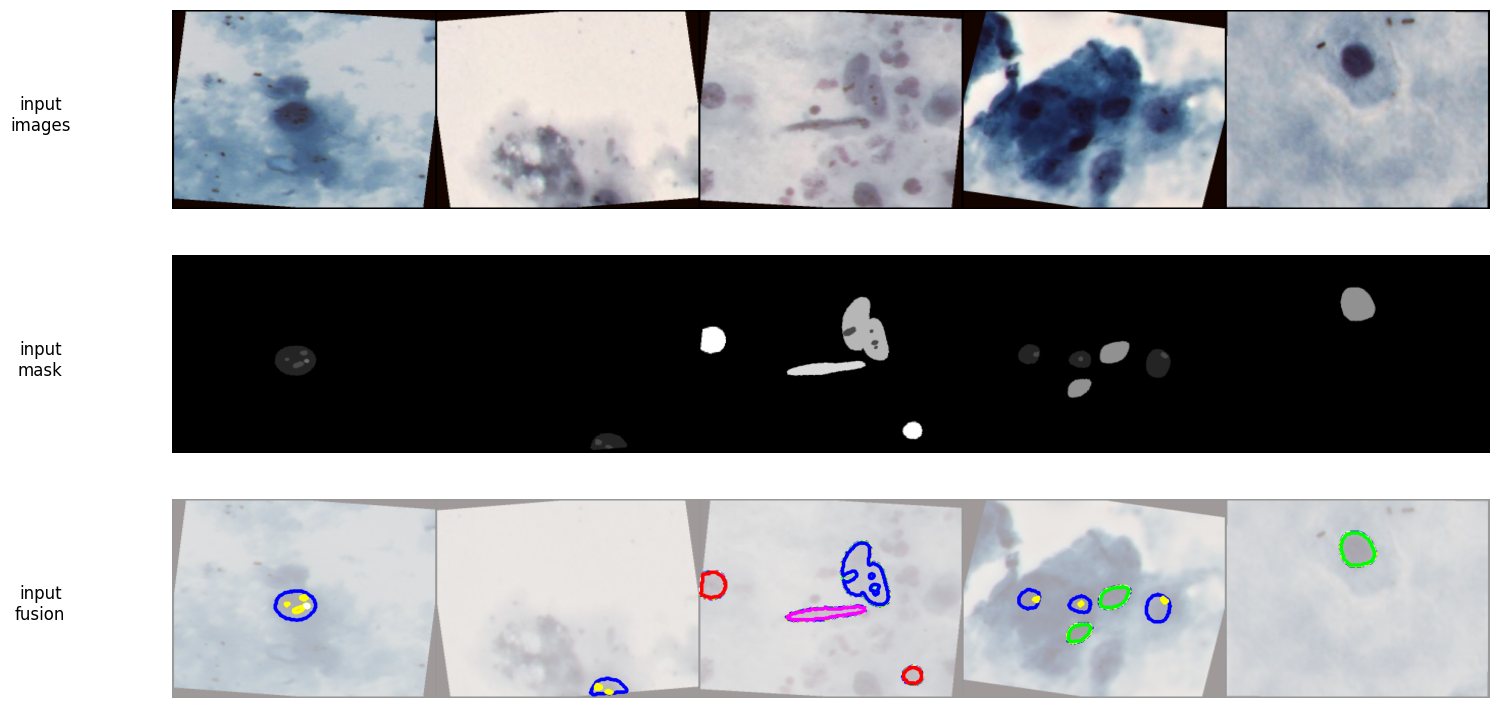

In [11]:

show_images(a[0], a[1].float(), mode=False)

## Training

In [12]:
#------------------------------------------
# 初始化模型、優化器、損失函數等
#------------------------------------------
unet = UNet(n_channels=3, n_classes=8).to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    unet = nn.DataParallel(unet)
else:
    print("Using single GPU or CPU")
    
optimizer = optim.Adam(unet.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=6, verbose=True)
grad_scaler = torch.cuda.amp.GradScaler(enabled=True)  # 啟用AMP

# Add Early Stopping
class EarlyStopping:
    def __init__(self, patience=6, delta=0, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

early_stopping = EarlyStopping(patience=10, verbose=True)

train_loss = []
val_loss = []
best_val_loss = float('inf')  # 初始化最佳驗證損失

for epoch in range(EPOCHS):
    unet.train()
    epoch_loss = 0
    i_bar = tqdm(trainloader, unit='iter', desc=f'epoch{epoch}')

    current_lr = optimizer.param_groups[0]['lr']

    for (imgs, masks) in i_bar:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=True):
            preds = unet(imgs)
            loss = criterion(preds, masks)
        grad_scaler.scale(loss).backward()
        grad_scaler.step(optimizer)
        grad_scaler.update()
        epoch_loss += loss.item()
        i_bar.set_postfix(loss=loss.item())
    train_loss.append(epoch_loss / len(trainloader))

    # Validation
    with torch.no_grad():
        unet.eval()
        val_epoch_loss = 0
        for (imgs, masks) in valloader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.cuda.amp.autocast(enabled=True):
                preds = unet(imgs)
                loss = criterion(preds, masks)
            val_epoch_loss += loss.item()
        val_epoch_loss /= len(valloader)
        val_loss.append(val_epoch_loss)

    print(f"Epoch {epoch}: Train Loss: {epoch_loss / len(trainloader):.4f}, Val Loss: {val_epoch_loss:.4f}, Learning Rate: {current_lr:.6f}")
    print("----------------------------------------------")
    scheduler.step(val_epoch_loss)

    # 若當前驗證 loss 優於最佳值，保存權重
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        # 如果模型使用 DataParallel，需要使用 model.module.state_dict()
        if isinstance(unet, nn.DataParallel):
            torch.save(unet.module.state_dict(), 'best_model.pth')
        else:
            torch.save(unet.state_dict(), 'best_model.pth')
        print("Best model saved.")

    early_stopping(val_epoch_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

Using single GPU or CPU


epoch0: 100%|██████████| 459/459 [07:52<00:00,  1.03s/iter, loss=0.444]


Epoch 0: Train Loss: 0.8716, Val Loss: 0.4496, Learning Rate: 0.000100
----------------------------------------------
Best model saved.


epoch1: 100%|██████████| 459/459 [07:05<00:00,  1.08iter/s, loss=0.18] 


Epoch 1: Train Loss: 0.2867, Val Loss: 0.1847, Learning Rate: 0.000100
----------------------------------------------
Best model saved.


...

Epoch 58: Train Loss: 0.0242, Val Loss: 0.0417, Learning Rate: 0.000064
----------------------------------------------
EarlyStopping counter: 8 out of 10


epoch59: 100%|██████████| 459/459 [07:05<00:00,  1.08iter/s, loss=0.0225]


Epoch 59: Train Loss: 0.0239, Val Loss: 0.0432, Learning Rate: 0.000064
----------------------------------------------
EarlyStopping counter: 9 out of 10


epoch60: 100%|██████████| 459/459 [07:06<00:00,  1.08iter/s, loss=0.0146]


Epoch 60: Train Loss: 0.0234, Val Loss: 0.0433, Learning Rate: 0.000064
----------------------------------------------
EarlyStopping counter: 10 out of 10
Early stopping triggered


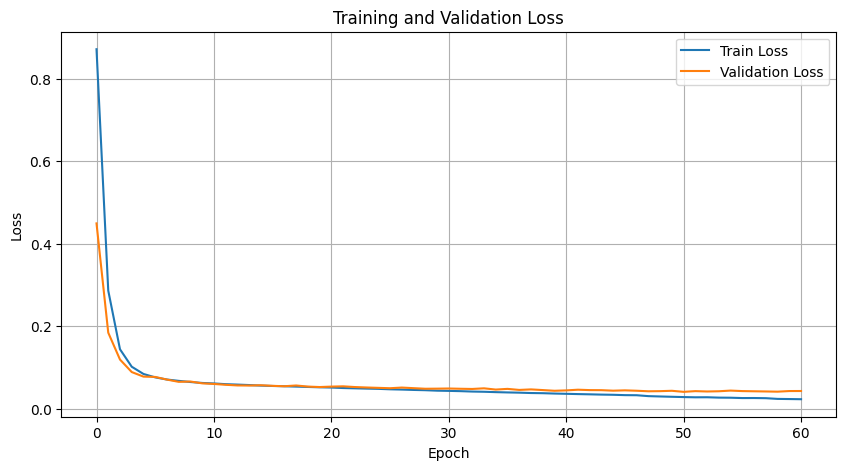

In [13]:
# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.grid()
plt.savefig('Training_and_Validation_Loss.png')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Image saved to ./version1_show_20241221_015408.png


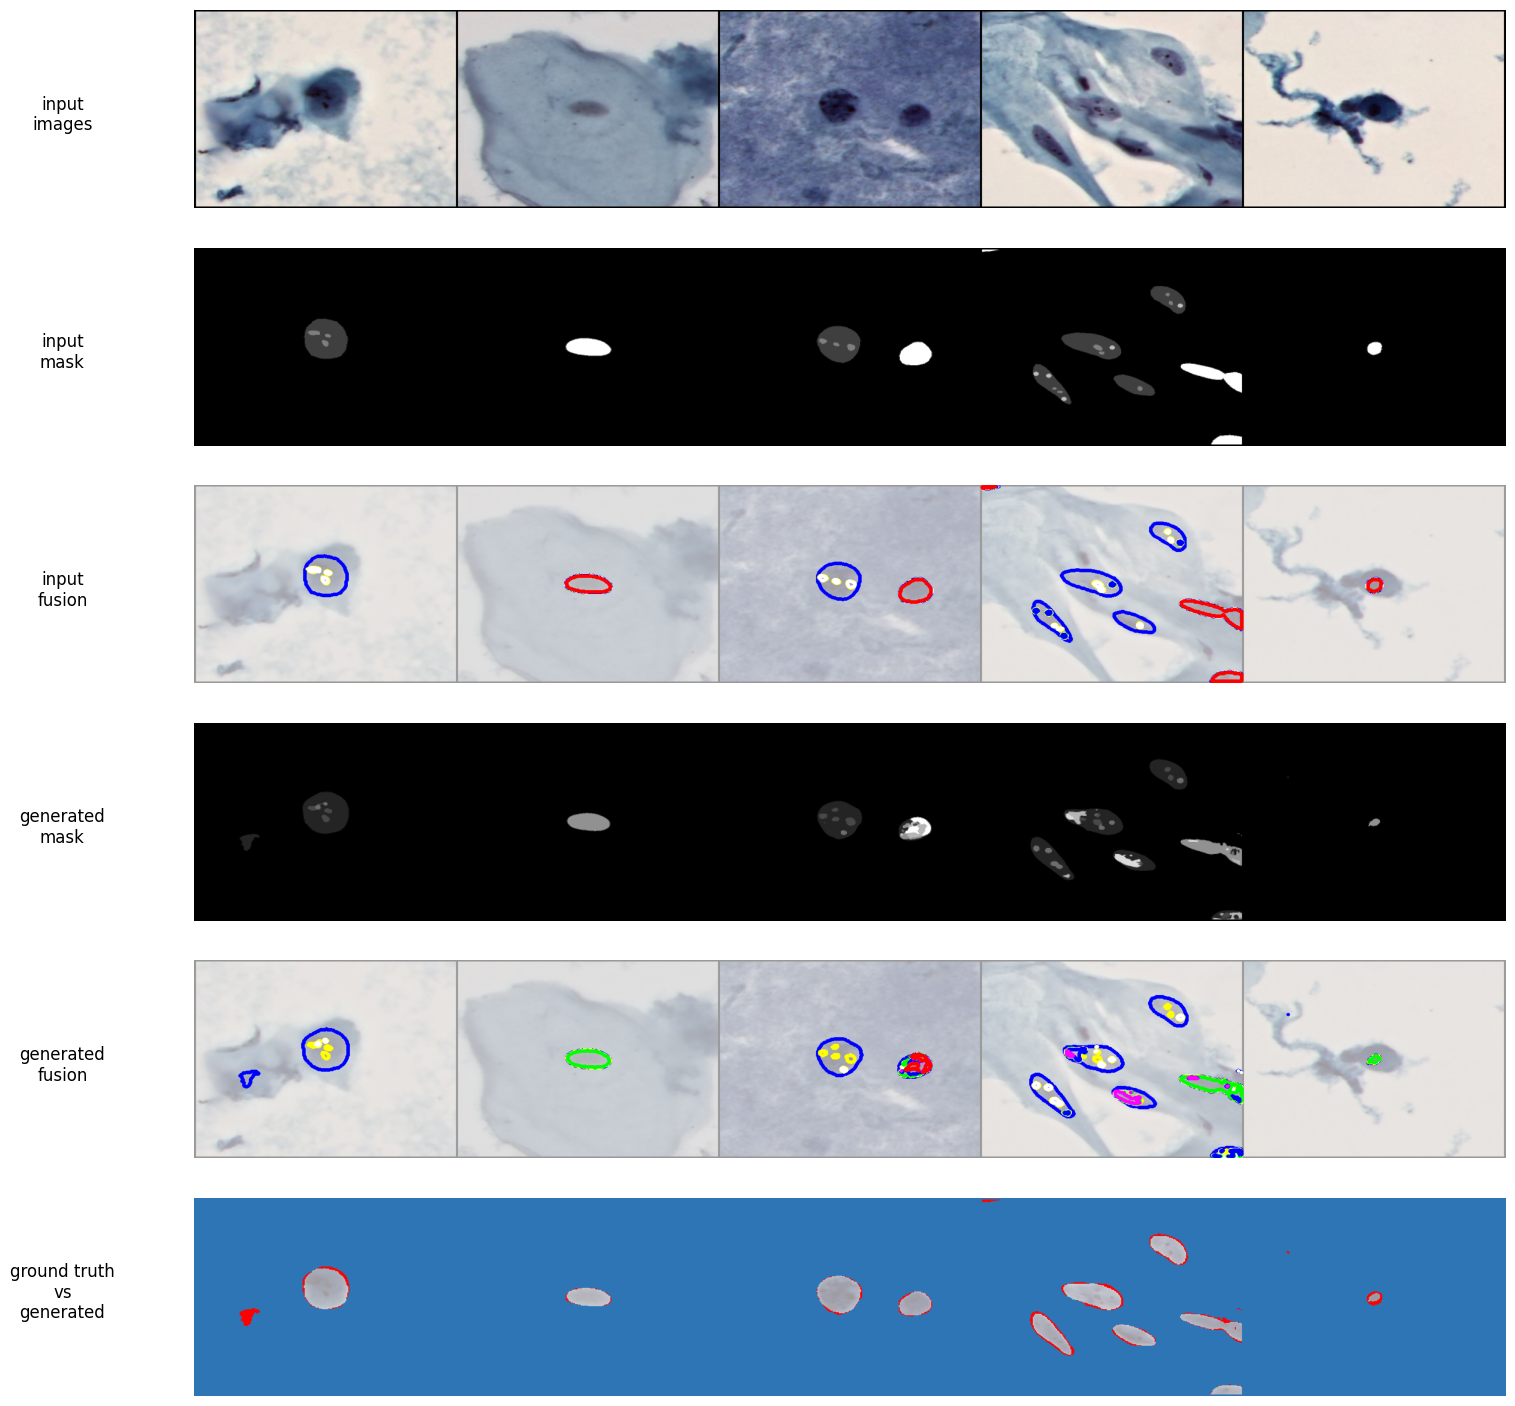

Evaluation Metrics on Test Set:
PA: 0.9867230653762817
cPA: 0.6124931573867798
mPA: 0.6124931573867798
Dice: 0.648854672908783
IoU: 0.5188580751419067
mIoU: 0.5188580751419067
mAP@[.5:.95:.05]: 0.25


In [14]:
#------------------------------------------
# 評估指標函數
#------------------------------------------
def get_confusion_matrix(pred, target, num_classes=8):
    mask = (target >= 0) & (target < num_classes)
    hist = torch.bincount(
        target[mask] * num_classes + pred[mask],
        minlength=num_classes ** 2,
    ).reshape(num_classes, num_classes)
    return hist

def calculate_metrics(loader, model, num_classes=8):
    model.eval()
    hist = torch.zeros(num_classes, num_classes)
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            preds = F.softmax(preds, dim=1)
            preds = torch.argmax(preds, dim=1)
            for i in range(preds.size(0)):
                hist += get_confusion_matrix(preds[i].cpu(), masks[i].cpu(), num_classes=num_classes)

    pa = torch.diag(hist).sum() / hist.sum()
    cpa = torch.diag(hist) / hist.sum(dim=1)
    mpa = cpa.mean()
    iou = torch.diag(hist) / (hist.sum(dim=1) + hist.sum(dim=0) - torch.diag(hist))
    miou = iou.mean()
    dice = 2*torch.diag(hist) / (2*torch.diag(hist) + hist.sum(dim=1) - torch.diag(hist) + hist.sum(dim=0) - torch.diag(hist))
    mdice = dice.mean()

    thresholds = torch.arange(0.5,1.0,0.05)
    aps = []
    for t in thresholds:
        aps.append((iou > t).float().mean())
    map_val = torch.mean(torch.tensor(aps))

    metrics = {
        "PA": pa.item(),
        "cPA": cpa.mean().item(),
        "mPA": mpa.item(),
        "Dice": mdice.item(),
        "IoU": iou.mean().item(),
        "mIoU": miou.item(),
        "mAP@[.5:.95:.05]": map_val.item()
    }
    return metrics

# 測試階段：選擇使用最佳權重進行測試
# 假設您中斷再運行測試時，需要先載入最佳權重
if isinstance(unet, nn.DataParallel):
    unet.module.load_state_dict(torch.load('best_model.pth', map_location=device))
else:
    unet.load_state_dict(torch.load('best_model.pth', map_location=device))
unet.eval()

imgs, masks = next(iter(testloader))
imgs, masks = imgs.to(device), masks.to(device)
with torch.no_grad():
    masks_pred = unet(imgs)
    masks_pred_softmax = F.softmax(masks_pred, dim=1)

pred2show = compress_channel(masks_pred_softmax.cpu(), 0.1)
show_images(imgs.cpu(), masks.cpu().float(), gen_masks=pred2show , mode=True)

# 計算並輸出測試集上的指標
metrics = calculate_metrics(testloader, unet, num_classes=8)
print("Evaluation Metrics on Test Set:")
for k,v in metrics.items():
    print(f"{k}: {v}")